In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def heaviside(z):
    return np.where(z >= 0, 1, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def heaviside_derivative(z):
    return np.zeros_like(z)

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

def relu_derivative(z):
    return np.where(z > 0, 1, 0)


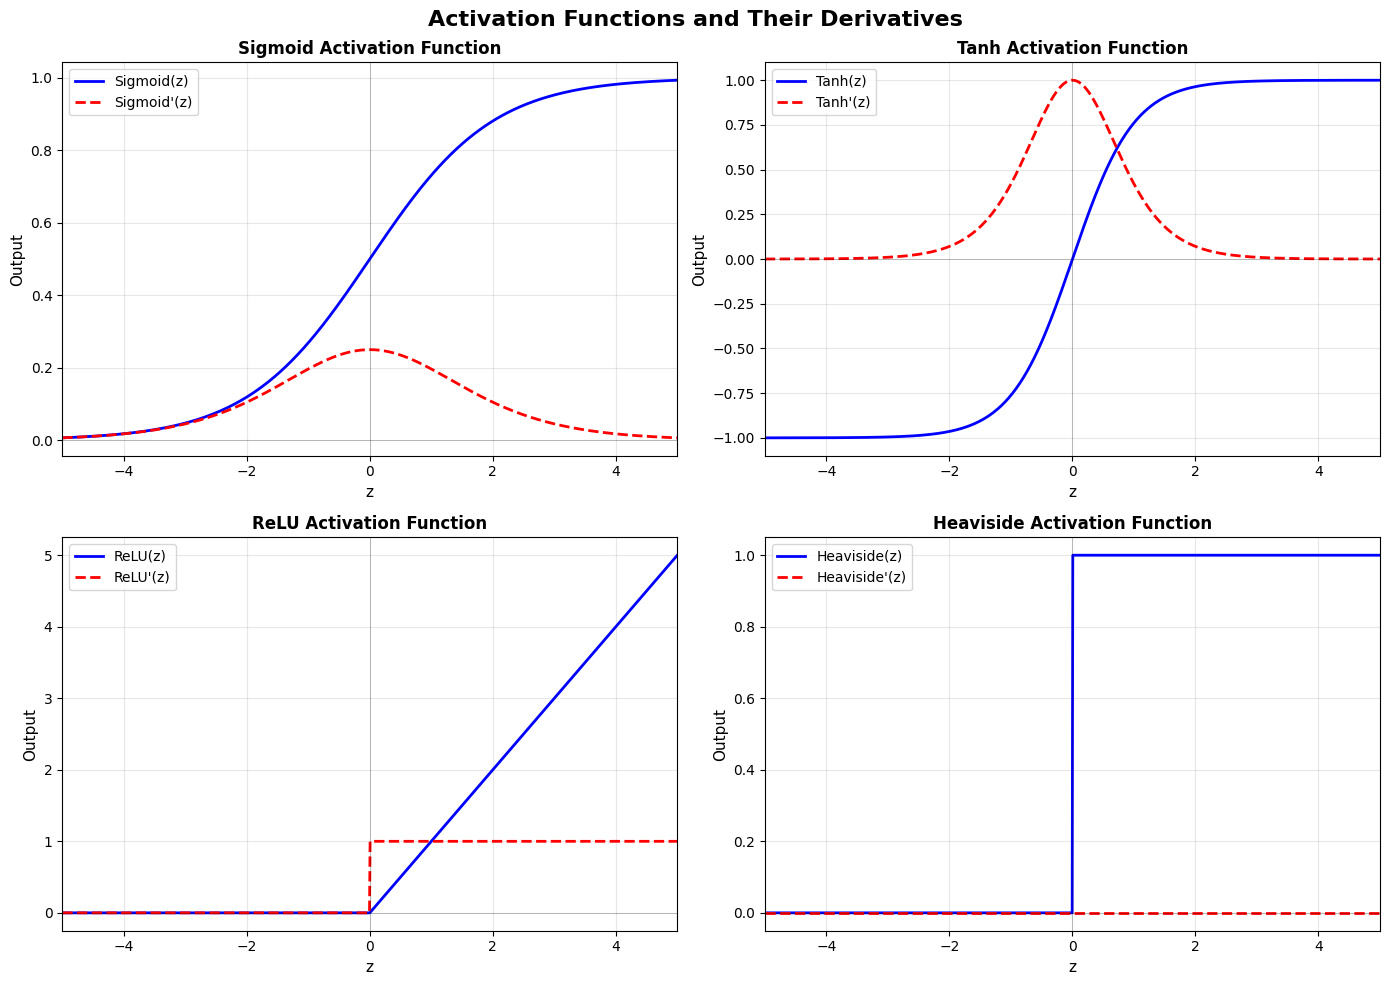

In [5]:
z = np.linspace(-5, 5, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Activation Functions and Their Derivatives', fontsize=16, fontweight='bold')

functions = [
    ('Sigmoid', sigmoid, sigmoid_derivative),
    ('Tanh', tanh, tanh_derivative),
    ('ReLU', relu, relu_derivative),
    ('Heaviside', heaviside, heaviside_derivative)
]

for idx, (name, func, deriv) in enumerate(functions):
    ax = axes[idx // 2, idx % 2]
    y = func(z)
    dy = deriv(z)
    ax.plot(z, y, 'b-', linewidth=2, label=f'{name}(z)')
    ax.plot(z, dy, 'r--', linewidth=2, label=f"{name}'(z)")
    
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('z', fontsize=11)
    ax.set_ylabel('Output', fontsize=11)
    ax.set_title(f'{name} Activation Function', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlim([-5, 5])

plt.tight_layout()
plt.show()


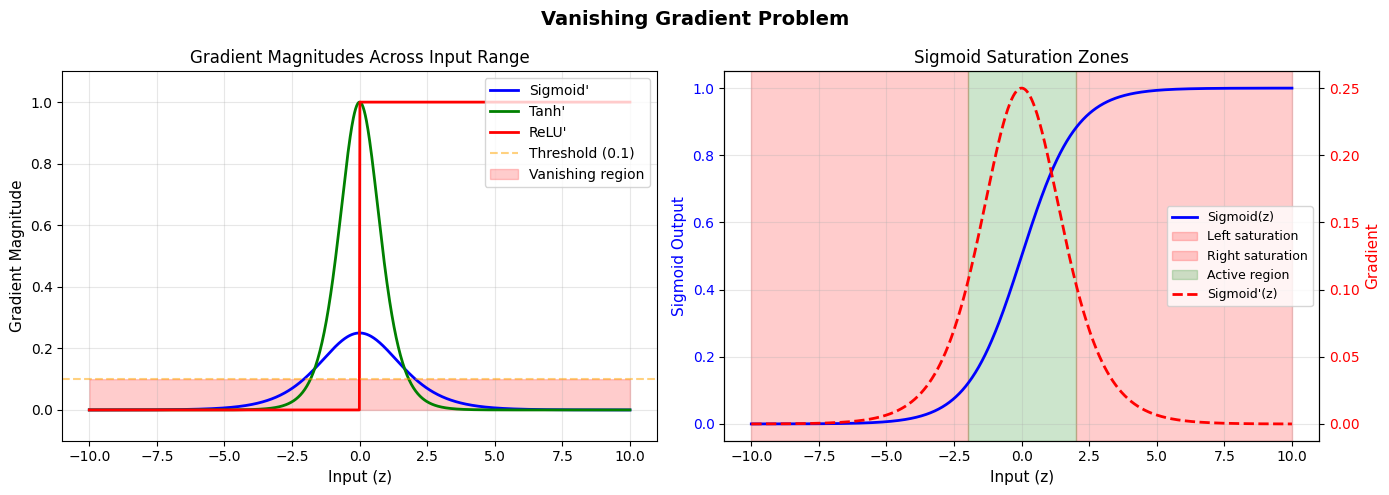

In [8]:
z = np.linspace(-10, 10, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vanishing Gradient Problem', fontsize=14, fontweight='bold')

ax1.plot(z, sigmoid_derivative(z), 'b-', linewidth=2, label='Sigmoid\'')
ax1.plot(z, tanh_derivative(z), 'g-', linewidth=2, label='Tanh\'')
ax1.plot(z, relu_derivative(z), 'r-', linewidth=2, label='ReLU\'')
ax1.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='Threshold (0.1)')
ax1.fill_between(z, 0, 0.1, alpha=0.2, color='red', label='Vanishing region')
ax1.set_xlabel('Input (z)', fontsize=11)
ax1.set_ylabel('Gradient Magnitude', fontsize=11)
ax1.set_title('Gradient Magnitudes Across Input Range', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-0.1, 1.1])

sig_vals = sigmoid(z)
sig_deriv = sigmoid_derivative(z)

ax2_twin = ax2.twinx()
ax2.plot(z, sig_vals, 'b-', linewidth=2, label='Sigmoid(z)')
ax2_twin.plot(z, sig_deriv, 'r--', linewidth=2, label="Sigmoid'(z)")

ax2.axvspan(-10, -2, alpha=0.2, color='red', label='Left saturation')
ax2.axvspan(2, 10, alpha=0.2, color='red', label='Right saturation')
ax2.axvspan(-2, 2, alpha=0.2, color='green', label='Active region')

ax2.set_xlabel('Input (z)', fontsize=11)
ax2.set_ylabel('Sigmoid Output', fontsize=11, color='b')
ax2_twin.set_ylabel('Gradient', fontsize=11, color='r')
ax2.set_title('Sigmoid Saturation Zones', fontsize=12)
ax2.tick_params(axis='y', labelcolor='b')
ax2_twin.tick_params(axis='y', labelcolor='r')
ax2.grid(True, alpha=0.3)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='right', fontsize=9)

plt.tight_layout()
plt.show()


1. With gradient equals 0 almost everywhere weighets in gradient descent would never update

2. Derivative of sigmoid function reaches maximum at $x=0$ with value equal to $\frac{1}{4}$

3. When inputs become large e.g. |z| > 5, sigmoid and tanh derivatives approach zero which causes slow learning. The more layers in network, the more multiplications of small numbers, leading to vanishing gradients.

4. Gradient of ReLU is 1 for z > 0 so there's no vanishing gradient problem

In [11]:
test_values = np.array([-10, -1, 0, 1, 10])

results = {
    'z': test_values,
    'Sigmoid\'': sigmoid_derivative(test_values),
    'Tanh\'': tanh_derivative(test_values),
    'ReLU\'': relu_derivative(test_values),
    'Heaviside\'': heaviside_derivative(test_values)
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

  z  Sigmoid'        Tanh'  ReLU'  Heaviside'
-10  0.000045 8.244615e-09      0           0
 -1  0.196612 4.199743e-01      0           0
  0  0.250000 1.000000e+00      0           0
  1  0.196612 4.199743e-01      1           0
 10  0.000045 8.244615e-09      1           0
